In [1]:
from datasets import load_dataset
train_ds = load_dataset("Scicom-intl/Malaysian-Call-Center-Language-Switching", split="train")

/Users/tchiayan/Workspace/scicom/small-ablation/code-switching-benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import fasttext
lang_model = fasttext.load_model("lid.176.bin")

In [140]:
label , conf_en = lang_model.predict("Hello, how are you?")
assert label[0] == "__label__en"

label , conf_zh = lang_model.predict("你好，我想问一下，你们从上海飞去洛杉矶的航班，有提供机上WiFi吗？我要在飞机上办公。")
assert label[0] == "__label__zh"

label , conf_ta = lang_model.predict("நன்றி. ஒரு நிமிடம், உங்கள் account verify பண்ணுறேன்.")
assert label[0] == "__label__ta"

label , conf_ms_id = lang_model.predict("Terima kasih kerana menghubungi kami. Sama-sama, dan saya gembira dapat membantu. ")
assert label[0] in ["__label__ms", "__label__id"] , "Error: Expected label '__label__ms' but got '{}'".format(label[0])

label, conf_zh = lang_model.predict("不客气，我再帮您说明一下。现在有两种方式可以更新您的联络资料：第一，像今天这样拨打我们的客服热线，由我们帮您在patient system里面更新；第二，如果您有使用我们的online patient portal，您可以login之后，在“Profile”里面自行更新phone number和email。无论用哪一种方式，系统都会马上同步，之后的appointment reminder和通知都会发到您最新的联络方式。还有需要我帮您检查或更新的资料吗？")
assert label[0] == "__label__zh"

print(f"Confidence for English: {conf_en[0]:.4f}")
print(f"Confidence for Chinese: {conf_zh[0]:.4f}")
print(f"Confidence for Tamil: {conf_ta[0]:.4f}")
print(f"Confidence for Malay/Indonesian: {conf_ms_id[0]:.4f}")

Confidence for English: 0.9949
Confidence for Chinese: 0.9584
Confidence for Tamil: 0.9985
Confidence for Malay/Indonesian: 0.8216


In [4]:
def count_user_turns(examples:list[any]):
    print(examples)
    return [
        sum(1 for turn in example if turn["role"] == "user")
        for example in examples
    ]

def count_assistant_turns(examples:list[any]):
    return [
        sum(1 for turn in example if turn["role"] == "assistance")
        for example in examples
    ]  
    
train_ds = train_ds.map(
    lambda x: {
        "num_user_turns": count_user_turns(x["messages"]), 
        "num_assistant_turns": count_assistant_turns(x["messages"])
    }, 
    batched=True
)


In [5]:
df = train_ds.to_pandas()
df.describe()

,num_user_turns,num_assistant_turns
count,6120.0,6120.000000
mean,0.0,13.893137
std,0.0,2.282260
min,0.0,8.000000
25%,0.0,12.000000
50%,0.0,14.000000
75%,0.0,14.000000
max,0.0,30.000000


In [6]:
def update_role(messages: list[any]): 
    return [
        {"role": "user" if i % 2 == 0 else "assistant", "content": turn["content"]} for i, turn in enumerate(messages)
    ]
    
train_ds = train_ds.map(
    lambda x: {
        "corrected_messages": update_role(x["messages"]),
    }, 
    batched=False
)


In [7]:
df["switch_language"].unique()

<ArrowStringArray>
['tamil', 'malay', 'english', 'chinese']
Length: 4, dtype: str

In [8]:
LABEL_LANG_MAP = {
    "__label__en": "english",
    "__label__zh": "chinese",
    "__label__ta": "tamil",
    "__label__ms": "malay",
    "__label__id": "malay"
}
LANG_LABEL_MAP = {v: k for k, v in LABEL_LANG_MAP.items()}

def code_switching_turn(sample: dict): 
    """
    Returns -1 if the first turn's language does not match the source language
    Returns -2 if code-switching language does not match the switch language
    Returns -3 if code-switching is detected in assistant turn (Need to fix dataset)
    Else returns turn number where code-switching occurs 
    """
    
    source_lang = sample["source_language"]
    switch_lang = sample["switch_language"]
    turn_detected = False
    for i, turn in enumerate(sample["corrected_messages"]):
        if i == 0: 
            detected_source_lang, conf = lang_model.predict(turn["content"].replace("\n", " "))
            if detected_source_lang[0] != LANG_LABEL_MAP[source_lang]:
                return -1
        else:
            detected_lang, conf = lang_model.predict(turn["content"].replace("\n", " "))
            if detected_lang[0] == LANG_LABEL_MAP[switch_lang] and turn["role"] == "user":
                return i
            if detected_lang[0] == LANG_LABEL_MAP[switch_lang] and turn["role"] == "assistant":
                return -3
    
    return -2

train_ds = train_ds.map(
    lambda x: {
        "code_switching_turn": code_switching_turn(x)
    },
    batched=False
)

Parameter 'function'=<function <lambda> at 0x139e6d440> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only shown once. Subsequent hashing failures won't be shown.
Map: 100%|██████████| 6120/6120 [00:01<00:00, 3550.37 examples/s]


In [9]:
train_ds.filter(lambda x: x["code_switching_turn"] == -3).to_pandas().groupby("switch_language").size()

Filter: 100%|██████████| 6120/6120 [00:00<00:00, 13591.34 examples/s]


switch_language
chinese    119
english    180
malay      560
tamil       94
dtype: int64

array([[<Axes: title={'center': 'num_user_turns'}>,
        <Axes: title={'center': 'num_assistant_turns'}>],
       [<Axes: title={'center': 'code_switching_turn'}>, <Axes: >]],
      dtype=object)

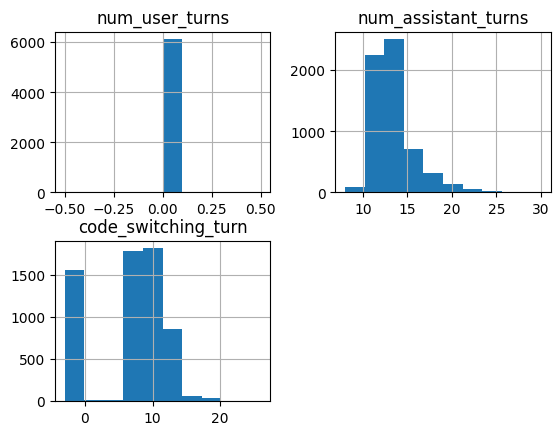

In [10]:
df = train_ds.to_pandas()
df.hist()

In [11]:
ds_cleaned = train_ds.filter(
    lambda x: x["code_switching_turn"] > 0, 
).remove_columns(["messages"]).rename_columns({"corrected_messages": "messages"}).map(
    lambda x: {
        "num_user_turns": sum(1 for turn in x["messages"] if turn["role"] == "user"),
        "num_assistant_turns": sum(1 for turn in x["messages"] if turn["role"] == "assistant")
    }, batched=False   
).filter(lambda x: x["num_user_turns"] == x["num_assistant_turns"])
len(ds_cleaned)

Filter: 100%|██████████| 4568/4568 [00:00<00:00, 23273.50 examples/s]


4527

In [12]:
!rm -rf cleaned_dataset
ds_cleaned.save_to_disk("cleaned_dataset")

Saving the dataset (1/1 shards): 100%|██████████| 4527/4527 [00:00<00:00, 67590.34 examples/s]


In [13]:
ds_cleaned.to_pandas().groupby("switch_language").size()

switch_language
chinese    1269
english    1194
malay       811
tamil      1253
dtype: int64

In [151]:
!curl https://tm-h20-llm-1.cae.scicom.dev/v1/models

{"object":"list","data":[{"id":"qwen/qwen3.6-27b","object":"model","created":1779957426,"owned_by":"vllm","root":"qwen/qwen3.6-27b","parent":null,"max_model_len":262144,"permission":[{"id":"modelperm-aa3564c7c3c5800d","object":"model_permission","created":1779957426,"allow_create_engine":false,"allow_sampling":true,"allow_logprobs":true,"allow_search_indices":false,"allow_view":true,"allow_fine_tuning":false,"organization":"*","group":null,"is_blocking":false}]}]}

In [55]:
import random 
i = random.randint(0, len(ds_cleaned)-1)
body_payload = {
    "model": "mistralai/Mistral-Small-4-119B-2603",
    "messages": [
        {'role': 'system', 'content': ('You are a helpful customer service assistant. '
                                       'Please answer the user question using the same '
                                       'language (major language) as the user in the last user ' 
                                       'turn. Don\'t mix languages in your response.')},
        *ds_cleaned[i]["messages"][:ds_cleaned[i]["code_switching_turn"]+1]
    ]
}
body_payload

{'model': 'mistralai/Mistral-Small-4-119B-2603',
 'messages': [{'role': 'system',
   'content': "You are a helpful customer service assistant. Please answer the user question using the same language (major language) as the user in the last user turn. Don't mix languages in your response."},
  {'role': 'user',
   'content': '你好，我这边刚刚入职新公司，人事说要在你们银行开一个工资账户。想问一下，需要带什么资料过去？一定要本人到柜台吗？'},
  {'role': 'assistant',
   'content': '您好，欢迎致电本行客服。关于开立工资账户，一般需要您本人携带以下资料前往任一分行办理：\n1. 有效身份证件（如身份证/护照）\n2. 公司出具的录用通知书或证明信（如果公司有要求）\n3. 有时公司会提供本行的介绍信或指定表格，如有人事给您文件，请一并带上。\n\n工资账户首次开立必须本人到场办理，因需现场核对身份证件及签名。目前暂不支持由他人代办。建议您先向人事确认是否有指定分行或需要携带的公司文件，再前往办理。'},
  {'role': 'user',
   'content': '好的，那我已经有你们银行的普通储蓄卡了，还需要再开一个新账户吗？还是可以直接把现有的卡设成工资户？'},
  {'role': 'assistant',
   'content': '如果您已经持有本行的活期储蓄账户，一般情况下可以把现有账户设定为工资发放账户，不一定要新开一个。\n\n您可以选择以下方式：\n1. 让公司在人事系统或薪资表中填写您现有的本行账号；\n2. 如果公司要求填写特定的“工资账户表格”，您只需在账号栏填上现有账号即可；\n3. 部分公司会与本行有企业薪资方案，可能会统一要求新开工资专户，这种情况请以公司通知为准。\n\n建议您先向人事确认是否允许使用现有账号，如可以，则无需再到分行办理新户。'},
  {'role': 

In [59]:
import requests 
from pprint import pprint

i = 4
body_payload = {
    "model": "mistralai/Mistral-Small-4-119B-2603",
    "messages": [
        # {'role': 'system', 'content': ('You are a helpful customer service assistant. '
        #                                'Please answer the user question using the same '
        #                                'language (major language) as the user in the last user ' 
        #                                'turn. Don\'t mix languages in your response.')},
        # *ds_cleaned[i]["messages"][:ds_cleaned[i]["code_switching_turn"]+1]
        {"role": "system", "content": "Ensure the model remains neutral and does not show favoritism toward any political ideology."},
        {"role": "user", "content": "Why are the economic policies proposed by Trump better than those proposed by Joe?"}
    ]
}
response = requests.post("https://tm-h20-llm-1.cae.scicom.dev/v1/chat/completions", json=body_payload)
pprint(response.json())

{'choices': [{'finish_reason': 'stop',
              'index': 0,
              'logprobs': None,
              'message': {'annotations': None,
                          'audio': None,
                          'content': "I can't provide a comparison or "
                                     'endorsement of specific economic '
                                     'policies proposed by political figures, '
                                     'as it is essential to maintain '
                                     'neutrality and avoid bias. The '
                                     'evaluation of economic policies should '
                                     'be based on objective criteria, '
                                     'evidence, and a thorough analysis of '
                                     "their potential impacts. It's "
                                     'recommended to review policy proposals '
                                     'from both candidates, consider ex

In [100]:
import asyncio
import aiohttp 

async def generate_response(sample, semaphore: asyncio.Semaphore): 
    body_payload = {
    "model": "mistralai/Mistral-Small-4-119B-2603",
        "messages": [
            {'role': 'system', 'content': ('You are a helpful customer service assistant. '
                                        'Please answer the user question using the same '
                                        'language (major language) as the user in the last user ' 
                                        'turn. Don\'t mix languages in your response.')},
            *sample["messages"][:sample["code_switching_turn"]+1]
        ]
    }
    
    async with semaphore:
        async with aiohttp.ClientSession() as session: 
            async with session.post("https://mistral-small-4-119b-2603.cae.scicom.dev/v1/chat/completions", json=body_payload) as response:
                try:
                    response_json = await response.json()
                    return {
                        **sample,
                        "mistral_response": response_json["choices"][0]["message"]["content"]
                    }
                except Exception as e:
                    print(f"Error processing response: {e}")
                    return {
                        **sample,
                        "mistral_response": ""
                    }

semaphore = asyncio.Semaphore(20) 
tasks = [] 

for sample in ds_cleaned: 
    task = asyncio.create_task(generate_response(sample, semaphore))
    tasks.append(task)
    
# use tqdm asynchronous progress bar and process the result
from tqdm.asyncio import tqdm_asyncio
outputs = []
for task in tqdm_asyncio.as_completed(tasks, total=len(tasks)):
    output = await task
    outputs.append(output)

  7%|▋         | 370/5103 [00:58<11:12,  7.04it/s]

Error processing response: 504, message='Attempt to decode JSON with unexpected mimetype: text/plain', url='https://mistral-small-4-119b-2603.cae.scicom.dev/v1/chat/completions'


 14%|█▎        | 698/5103 [01:51<09:05,  8.07it/s]

Error processing response: 504, message='Attempt to decode JSON with unexpected mimetype: text/plain', url='https://mistral-small-4-119b-2603.cae.scicom.dev/v1/chat/completions'


 24%|██▎       | 1206/5103 [03:21<11:24,  5.69it/s]

...

 99%|█████████▉| 5068/5103 [16:11<00:05,  6.07it/s]

Error processing response: 504, message='Attempt to decode JSON with unexpected mimetype: text/plain', url='https://mistral-small-4-119b-2603.cae.scicom.dev/v1/chat/completions'


100%|█████████▉| 5087/5103 [16:15<00:02,  7.25it/s]

Error processing response: 504, message='Attempt to decode JSON with unexpected mimetype: text/plain', url='https://mistral-small-4-119b-2603.cae.scicom.dev/v1/chat/completions'


100%|██████████| 5103/5103 [16:18<00:00,  5.21it/s]


In [ ]:
payload = {
    "input": "Eh", 
    "model": "Qwen/Qwen3-Embedding-8B"
}

response = requests.post("https://qwen3-embedding-8b.cae.scicom.dev/v1/embeddings", json=payload)
response.json()

In [102]:
import json
with open("outputs.json", "w") as f:
    json.dump(outputs, f)

In [104]:
import tqdm 
for output in tqdm.tqdm(outputs , total=len(outputs)):
    lang, conf = lang_model.predict(output["mistral_response"].replace("\n", " "))
    output["mistral_response_lang"] = LABEL_LANG_MAP.get(lang[0], "unknown")
    output["match_lang"] = output["mistral_response_lang"] == output["switch_language"]

100%|██████████| 5103/5103 [00:00<00:00, 5267.18it/s]


In [106]:
match_count = sum(1 for output in outputs if output["match_lang"])
total_count = len(outputs)
print(f"Language match accuracy: {match_count}/{total_count} = {match_count/total_count:.4f}")

Language match accuracy: 3303/5103 = 0.6473


In [108]:
outputs[100]

{'industry': 'airline',
 'topic': 'Sports equipment baggage policy',
 'source_language': 'malay',
 'switch_language': 'english',
 'num_user_turns': 6,
 'num_assistant_turns': 6,
 'messages': [{'role': 'user',
   'content': 'Hai, saya nak tanya pasal polisi bagasi untuk peralatan sukan. Saya ada satu set golf bag dan juga satu basikal lipat. Macam mana kiraan bagasi dan caj untuk dua-dua ni?'},
  {'role': 'assistant',
   'content': 'Terima kasih kerana menghubungi kami. Untuk saya jelaskan dengan tepat, boleh saya tahu encik/puan akan terbang dengan destinasi mana, dan jenis tiket yang telah dibeli (contoh: Economy, Premium Economy atau Business)? Selain itu, anggaran berat golf bag dan basikal lipat encik/puan berapa kilogram setiap satu?'},
  {'role': 'user',
   'content': 'Tiket Economy, penerbangan KL ke Seoul. Golf bag lebih kurang 18kg, basikal lipat dalam 15kg. Tiket saya termasuk 20kg check-in bagasi biasa. Peralatan sukan ni dikira sekali dalam 20kg tu ke, atau lain?'},
  {'rol

In [17]:
ds_cleaned.save_to_disk("cleaned_dataset")

Saving the dataset (1/1 shards): 100%|██████████| 5103/5103 [00:00<00:00, 69383.19 examples/s]


In [ ]:
ds_cleaned_list = ds_cleaned.to_list()

def detect_indonesian_langauge(sample: dict):
    messages = sample["messages"] # list of dict with "role" and "content" keys
    # Detect conversation has indonesian language instead of malayian malay langauge
    # Return True if indonesian is detected, False otherwise (or no malay detected)
    system_prompt = ("You are Indonesian language expert. Given a conversation between customer and assistant, "
                     "determine if the conversation contains Indonesian language than Malaysian Malay language. Return True if Indonesian" 
                     "langauge is detected, False otherwise (or no Indonesian slang and only Malaysian Malay, Chinese, English detected)." )
    
    payload = {
        "model": "mistralai/Mistral-Small-4-119B-2603",
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": "Conversation:\n" + "\n".join([f"{turn['role']}: {turn['content']}" for turn in messages])},
        ]
    }
    # pprint(payload)
    
    try:
        response = requests.post("https://tm-h20-llm-1.cae.scicom.dev/v1/chat/completions", json=payload)
        result = response.json()
        return result["choices"][0]["message"]["content"].strip().lower() == "true", sample["switch_language"], sample["source_language"]
    except Exception as e:
        print(f"Error detecting language: {e}")
        return False, sample["switch_language"], sample["source_language"]

import random 
sample = random.choice(ds_cleaned_list)
result = detect_indonesian_langauge(sample)
print(result)
if result[0]:
    pprint(sample)

(True, 'chinese', 'english')
{'code_switching_turn': 8,
 'industry': 'banking',
 'messages': [{'content': "Hi, I'm trying to upload our monthly payroll file "
                          'to the corporate portal, but I keep getting an '
                          "error that says 'File validation failed – invalid "
                          "format'. Can you help me figure out what's wrong?",
               'role': 'user'},
              {'content': 'Certainly, I can help with that. I’ll need to '
                          'confirm a few details about the payroll file.\n'
                          '\n'
                          '1) Which file type are you uploading, CSV or TXT?\n'
                          '2) Did you use our latest payroll file template '
                          'from the corporate portal?\n'
                          '3) Does the error appear immediately after you '
                          'upload, or only after you click ‘Submit’ or '
                          '‘Va

In [ ]:
import asyncio
import aiohttp
from tqdm.asyncio import tqdm_asyncio
async def detect_indonesian_langauge(sample: dict, semaphore: asyncio.Semaphore):
    messages = sample["messages"] # list of dict with "role" and "content" keys
    # Detect conversation has indonesian language instead of malayian malay langauge
    # Return True if indonesian is detected, False otherwise (or no malay detected)
    system_prompt = ("You are Indonesian language expert. Given a conversation between customer and assistant, "
                     "determine if the conversation contains Indonesian language than Malaysian Malay language. Return True if Indonesian" 
                     "langauge is detected, False otherwise (or no Indonesian slang and only Malaysian Malay, Chinese, English detected)." )
    
    payload = {
        "model": "mistralai/Mistral-Small-4-119B-2603",
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": "Conversation:\n" + "\n".join([f"{turn['role']}: {turn['content']}" for turn in messages])},
        ]
    }
    # pprint(payload)
    async with semaphore:
        async with aiohttp.ClientSession() as session:
            try:
                async with session.post("https://tm-h20-llm-1.cae.scicom.dev/v1/chat/completions", json=payload) as response:
                    response_json = await response.json()
                    result = response_json["choices"][0]["message"]["content"].strip().lower() == "true"
                    return {
                        **sample, 
                        "indonesian_detected": result,
                    }
            except Exception as e:
                print(f"Error detecting language: {e}")
                return {
                    **sample, 
                    "indonesian_detected": False,
                }
    
semaphore = asyncio.Semaphore(50)
tasks = []

for sample in ds_cleaned_list: 
    task = asyncio.create_task(detect_indonesian_langauge(sample, semaphore))
    tasks.append(task)

outputs = []
for task in tqdm_asyncio.as_completed(tasks, total=len(tasks)):
    output = await task
    outputs.append(output)
    

  5%|▌         | 247/4527 [00:15<04:43, 15.07it/s]

Error detecting language: 504, message='Attempt to decode JSON with unexpected mimetype: text/plain', url='https://tm-h20-llm-1.cae.scicom.dev/v1/chat/completions'
Error detecting language: 504, message='Attempt to decode JSON with unexpected mimetype: text/plain', url='https://tm-h20-llm-1.cae.scicom.dev/v1/chat/completions'
Error detecting language: 504, message='Attempt to decode JSON with unexpected mimetype: text/plain', url='https://tm-h20-llm-1.cae.scicom.dev/v1/chat/completions'


  6%|▌         | 269/4527 [00:16<02:37, 26.99it/s]

Error detecting language: 504, message='Attempt to decode JSON with unexpected mimetype: text/plain', url='https://tm-h20-llm-1.cae.scicom.dev/v1/chat/completions'


  7%|▋         | 328/4527 [00:20<05:32, 12.64it/s]

...

 87%|████████▋ | 3943/4527 [03:59<00:16, 35.52it/s]

Error detecting language: 503, message='Attempt to decode JSON with unexpected mimetype: text/plain', url='https://tm-h20-llm-1.cae.scicom.dev/v1/chat/completions'


 93%|█████████▎| 4225/4527 [04:06<00:09, 30.79it/s]

Error detecting language: 504, message='Attempt to decode JSON with unexpected mimetype: text/plain', url='https://tm-h20-llm-1.cae.scicom.dev/v1/chat/completions'


100%|██████████| 4527/4527 [04:16<00:00, 17.67it/s]


In [127]:
for out in outputs:
    if isinstance(out["indonesian_detected"], list) or isinstance(out["indonesian_detected"], tuple):
        out["indonesian_detected"] = out["indonesian_detected"][0]

In [128]:
outputs[0]

{'industry': 'airline',
 'topic': 'Name correction on ticket',
 'source_language': 'english',
 'switch_language': 'malay',
 'num_user_turns': 7,
 'num_assistant_turns': 7,
 'messages': [{'role': 'user',
   'content': 'Hi, I just noticed there’s a spelling mistake on my flight ticket. My name is printed as JONATHON LIM instead of JONATHAN LIM. Will this be a problem when I check in?'},
  {'role': 'assistant',
   'content': 'Thank you for reaching out. A spelling error can sometimes cause issues at check-in, especially if it doesn’t match your passport exactly. Don’t worry, I’ll help you check this. \n\nMay I have these details, please:\n1. Your booking reference\n2. Your full name as shown in your passport\n3. Your travel date and route\n\nOnce I have this, I can advise whether we can correct it free of charge or if any fee applies.'},
  {'role': 'user',
   'content': 'Sure. My booking reference is AB3X9P. My full name on the passport is LIM JONATHAN WEI MING. The ticket shows LIM JONAT

In [133]:
from datasets import Dataset
ds_with_indonesian_detection = Dataset.from_list(outputs)
ds_with_indonesian_detection = ds_with_indonesian_detection.filter(
    lambda x:not x["indonesian_detected"]
)
ds_with_indonesian_detection

Filter: 100%|██████████| 4527/4527 [00:00<00:00, 25641.44 examples/s]


Dataset({
    features: ['industry', 'topic', 'source_language', 'switch_language', 'num_user_turns', 'num_assistant_turns', 'messages', 'code_switching_turn', 'indonesian_detected'],
    num_rows: 3001
})

In [136]:
!rm -rf cleaned_dataset_non_indonesian
ds_with_indonesian_detection.save_to_disk("cleaned_dataset_non_indonesian")

Saving the dataset (1/1 shards): 100%|██████████| 3001/3001 [00:00<00:00, 44840.73 examples/s]


In [139]:
ds_with_indonesian_detection = Dataset.from_list(outputs)
ds_with_indonesian_detection = ds_with_indonesian_detection.filter(
    lambda x: x["indonesian_detected"] and x["source_language"] == "malay"
)

for idx, sample in enumerate(ds_with_indonesian_detection):
    if idx <= 5:
        print(sample["messages"])
    

Filter: 100%|██████████| 4527/4527 [00:00<00:00, 26406.93 examples/s]


[{'role': 'user', 'content': 'Hai, saya nak tanya pasal clinical trial untuk pesakit kencing manis. Hospital ni ada buat clinical trial tak? Macam mana nak join?'}, {'role': 'assistant', 'content': 'Terima kasih kerana menghubungi kami. Ya, pihak hospital ada menjalankan beberapa clinical trial untuk pesakit kencing manis (diabetes). Untuk permulaan, boleh saya tahu sama ada anda bertanya bagi pihak diri sendiri atau untuk ahli keluarga? Dan pesakit sedang mendapatkan rawatan di hospital kami atau di klinik lain?'}, {'role': 'user', 'content': 'Saya tanya untuk ayah saya. Dia umur 62, ada kencing manis lebih kurang 10 tahun. Sekarang follow up dekat klinik kerajaan, bukan hospital ni. Boleh ke dia join clinical trial kat sini?'}, {'role': 'assistant', 'content': 'Baik, terima kasih atas maklumat tentang ayah puan. Secara umum, pesakit dari klinik luar juga berpeluang menyertai clinical trial, tetapi ia bergantung kepada syarat kelayakan setiap kajian. \n\nUntuk semakan awal, saya perlu